<a href="https://colab.research.google.com/github/AbelPhilippe/DataScienceSalary-2020--2025-/blob/main/AI%2CML%2CDataScienceSalary(2020_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT DATASET**

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samithsachidanandan/the-global-ai-ml-data-science-salary-for-2025")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/the-global-ai-ml-data-science-salary-for-2025


# **IMPORT LIBS**

In [73]:
import os
import pandas as pd
import sklearn.model_selection
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pandas.plotting import scatter_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# **DATASET VISUALIZATION**

In [46]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/samithsachidanandan/the-global-ai-ml-data-science-salary-for-2025/versions/1/salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M
3,2025,SE,FT,Applied Scientist,294000,USD,294000,US,0,US,M
4,2025,SE,FT,Applied Scientist,137600,USD,137600,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
88579,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
88580,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
88581,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
88582,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [47]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [48]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,88584.000000,8.858400e+04,88584.000000,88584.000000
mean,2024.034758,1.619323e+05,157567.798417,21.286011
std,0.620370,1.965317e+05,73531.373158,40.831018
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,106097.250000,0.000000
50%,2024.000000,1.470000e+05,146307.000000,0.000000
75%,2024.000000,1.995000e+05,198600.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88584 entries, 0 to 88583
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           88584 non-null  int64 
 1   experience_level    88584 non-null  object
 2   employment_type     88584 non-null  object
 3   job_title           88584 non-null  object
 4   salary              88584 non-null  int64 
 5   salary_currency     88584 non-null  object
 6   salary_in_usd       88584 non-null  int64 
 7   employee_residence  88584 non-null  object
 8   remote_ratio        88584 non-null  int64 
 9   company_location    88584 non-null  object
 10  company_size        88584 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.4+ MB


In [49]:
df.duplicated().sum()

np.int64(44340)

In [50]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

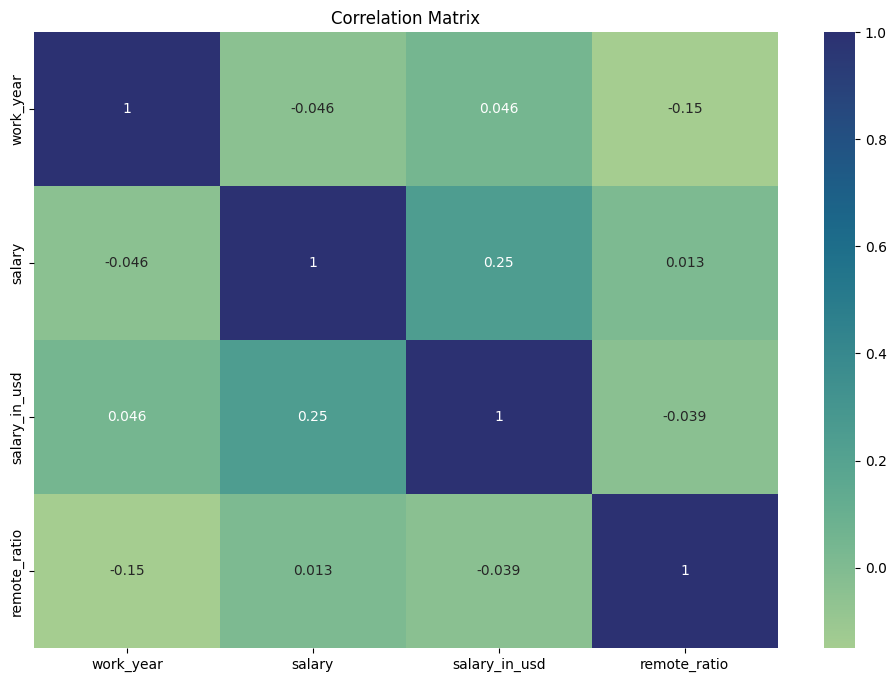

In [51]:
correlation_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'crest')
sns.color_palette("mako", as_cmap=True)
plt.title('Correlation Matrix')
plt.show()

In [52]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [53]:
graph = px.treemap(df, path=['experience_level', 'job_title'])
graph.show()

In [54]:
graph = px.treemap(df, path=['job_title', 'company_size'])
graph.show()

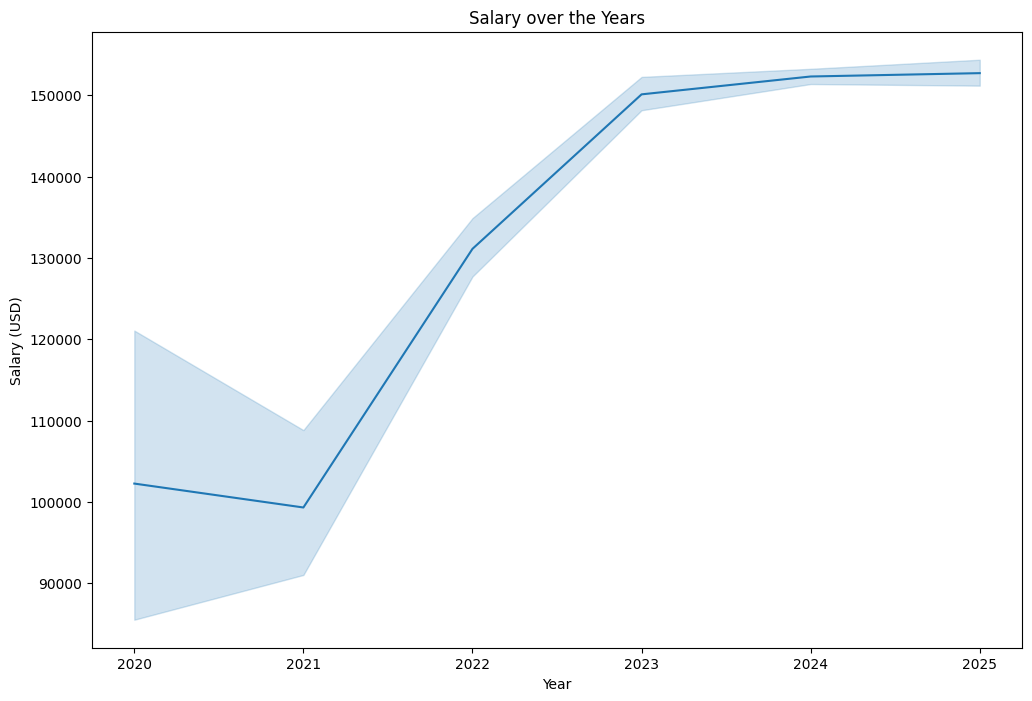

In [55]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='work_year', y='salary_in_usd', data=df)
plt.title('Salary over the Years')
plt.xlabel('Year')
plt.ylabel('Salary (USD)')
plt.show()

In [57]:
employee_counts = df['employee_residence'].value_counts()
N = 10
top_countries = employee_counts.head(N)
print(top_countries)


employee_residence
US    37388
CA     2460
GB     1812
AU      264
DE      230
FR      186
LT      171
NL      168
IN      140
ES      136
Name: count, dtype: int64


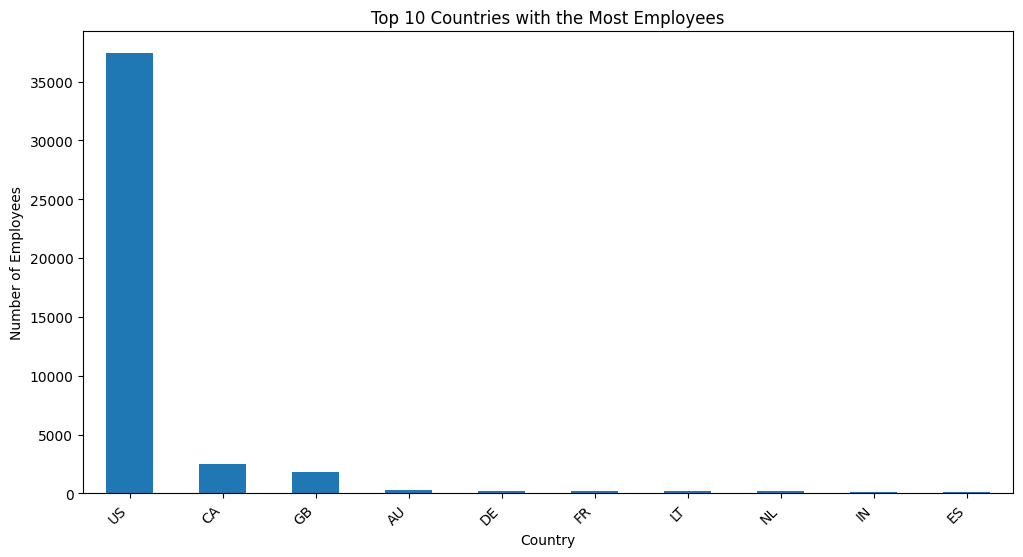

In [58]:
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar')
plt.title(f'Top {N} Countries with the Most Employees')
plt.xlabel('Country')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.show()

In [60]:
top_cargos = df['job_title'].value_counts().head(10)
print(top_cargos)

job_title
Data Scientist               5207
Data Engineer                4916
Data Analyst                 4355
Software Engineer            3009
Machine Learning Engineer    2583
Engineer                     2515
Manager                      2010
Analyst                      1303
Research Scientist           1027
Analytics Engineer            922
Name: count, dtype: int64


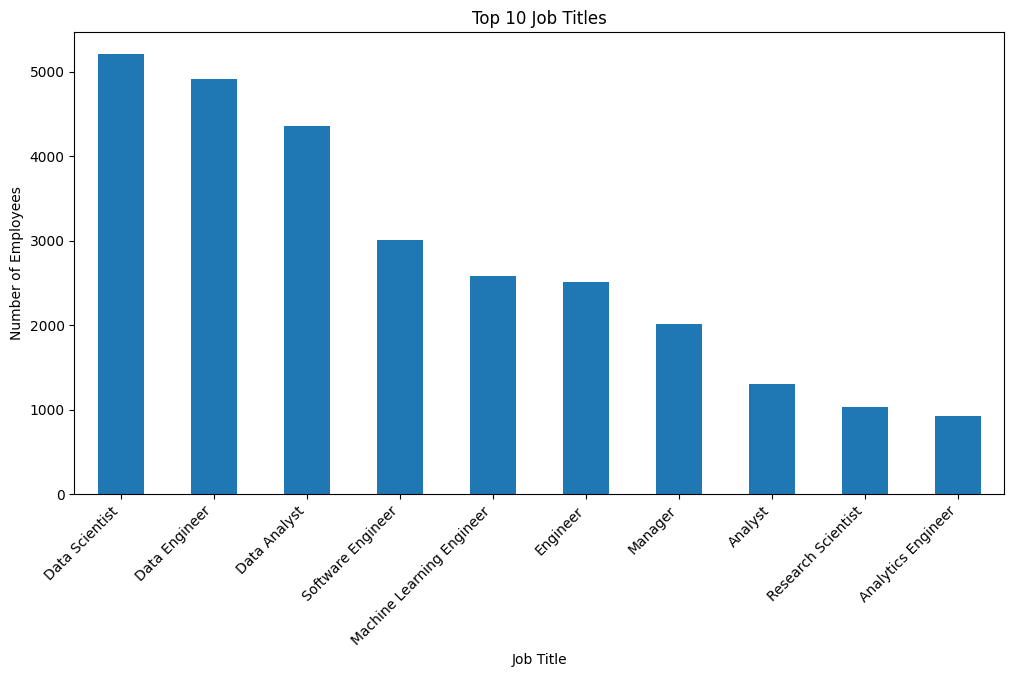

In [61]:
plt.figure(figsize=(12, 6))
top_cargos.plot(kind='bar')
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.show()

In [66]:
average_salaries = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False)
top_countries = average_salaries.head(N)
print(f"Top {N} countries with the highest average salaries in USD:")
print(top_countries)

Top 10 countries with the highest average salaries in USD:
employee_residence
QA    300000.000000
VE    192500.000000
CZ    189519.777778
US    159918.177169
IL    158422.888889
PR    146488.888889
SA    139999.333333
MY    134615.500000
EG    133318.750000
CA    130595.605691
Name: salary_in_usd, dtype: float64


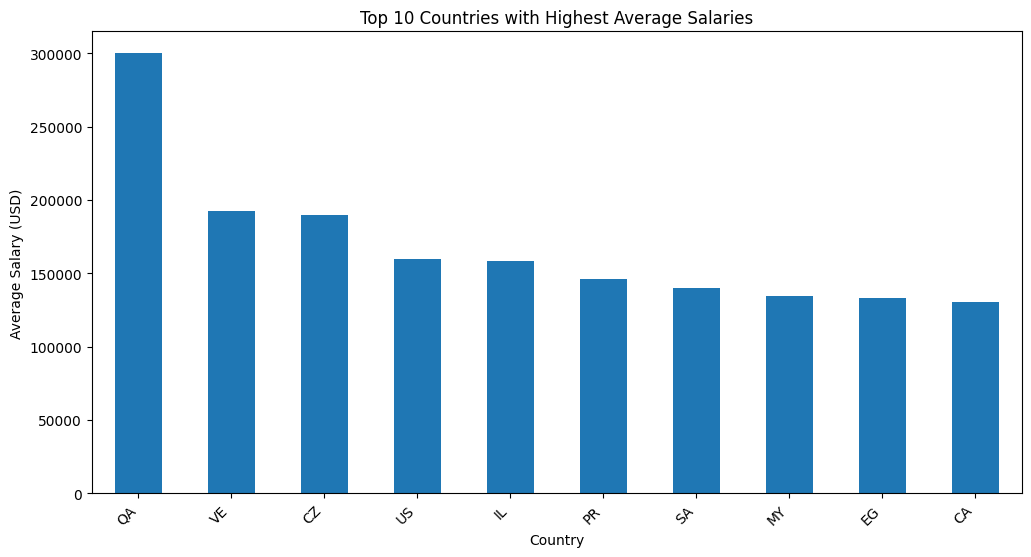

In [67]:
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar')
plt.title(f'Top {N} Countries with Highest Average Salaries')
plt.xlabel('Country')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.show()

# **MODELS**

In [74]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'SGDRegressor': SGDRegressor(),
    'KNN': KNeighborsRegressor(),
}

In [75]:
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']

for col in X.select_dtypes(include='object').columns:
    dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
    X = pd.concat([X.drop(columns=[col]), dummies], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [76]:
X_train, X_test

(       work_year  salary  remote_ratio  experience_level_EX  \
 38101       2024  324000           100                False   
 14021       2025  287500             0                False   
 65977       2024  106000             0                False   
 19044       2024  234700             0                False   
 47079       2024   86462             0                False   
 ...          ...     ...           ...                  ...   
 8361        2025  147000             0                False   
 16608       2024  440000             0                False   
 77620       2024  134600             0                False   
 956         2025  100900           100                False   
 22627       2024   81250             0                False   
 
        experience_level_MI  experience_level_SE  employment_type_FL  \
 38101                False                 True               False   
 14021                False                 True               False   
 65977        

# **STANDARLIZATION**

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit no treino
X_test_scaled = scaler.transform(X_test)        # Transform no teste

X_train = X_train_scaled
X_test = X_test_scaled

In [78]:
X_train, X_test

(array([[-0.09245652,  0.63247426,  1.75410461, ..., -0.00531539,
          0.18603428, -0.0702868 ],
        [ 1.31024329,  0.49197628, -0.57507204, ..., -0.00531539,
          0.18603428, -0.0702868 ],
        [-0.09245652, -0.20666437, -0.57507204, ..., -0.00531539,
          0.18603428, -0.0702868 ],
        ...,
        [-0.09245652, -0.09657554, -0.57507204, ..., -0.00531539,
          0.18603428, -0.0702868 ],
        [ 1.31024329, -0.22629559,  1.75410461, ..., -0.00531539,
          0.18603428, -0.0702868 ],
        [-0.09245652, -0.30193355, -0.57507204, ..., -0.00531539,
          0.18603428, -0.0702868 ]]),
 array([[-9.24565239e-02, -3.27916052e-01, -5.75072035e-01, ...,
         -5.31539051e-03,  1.86034275e-01, -7.02868019e-02],
        [-9.24565239e-02, -1.13144360e-02, -5.75072035e-01, ...,
         -5.31539051e-03,  1.86034275e-01, -7.02868019e-02],
        [ 1.31024329e+00,  1.31108175e-01, -5.75072035e-01, ...,
         -5.31539051e-03,  1.86034275e-01, -7.02868019e-

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    score_train = model.score(X_train, y_train)
    score_test = model.score(X_test, y_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    print(f"\nMetrics for {name}:")
    print(f"Train Score: {score_train}")
    print(f"Test Score: {score_test}")
    print(f"Mean Squared Error (Train): {mse_train}")
    print(f"Mean Squared Error (Test): {mse_test}")
    print(f"R-squared (Test): {r2}")


Metrics for Linear Regression:
Train Score: 0.621812464683033
Test Score: -0.8438726681515052
Mean Squared Error (Train): 2258068823.0293026
Mean Squared Error (Test): 11111145300.038822
R-squared (Test): -0.8438726681515052
